In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pandas import set_option

from sklearn.model_selection import train_test_split

df = pd.read_csv("bodyfat.csv")
df.head()

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,1.0708,12.3,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,1.0853,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,1.0414,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,1.0751,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,1.0340,28.7,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Density  252 non-null    float64
 1   BodyFat  252 non-null    float64
 2   Age      252 non-null    int64  
 3   Weight   252 non-null    float64
 4   Height   252 non-null    float64
 5   Neck     252 non-null    float64
 6   Chest    252 non-null    float64
 7   Abdomen  252 non-null    float64
 8   Hip      252 non-null    float64
 9   Thigh    252 non-null    float64
 10  Knee     252 non-null    float64
 11  Ankle    252 non-null    float64
 12  Biceps   252 non-null    float64
 13  Forearm  252 non-null    float64
 14  Wrist    252 non-null    float64
dtypes: float64(14), int64(1)
memory usage: 29.7 KB


In [ ]:
X = df.iloc[:, np.r_[0:1, 2:15]].values
Y = df.iloc[:, 1].values

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.5)

In [ ]:
X_train

array([[  1.053 ,  41.    , 172.75  , ...,  31.    ,  29.2   ,  18.4   ],
       [  1.065 ,  55.    , 169.5   , ...,  33.4   ,  29.3   ,  18.8   ],
       [  1.083 ,  26.    , 186.25  , ...,  32.8   ,  29.4   ,  18.5   ],
       ...,
       [  1.0543,  49.    , 168.25  , ...,  29.5   ,  27.9   ,  18.6   ],
       [  1.0373,  42.    , 177.5   , ...,  33.8   ,  30.3   ,  17.2   ],
       [  1.0841,  42.    , 167.25  , ...,  30.6   ,  30.    ,  18.5   ]])

In [ ]:
Y_train

array([20.1, 14.8,  7.1,  8. ,  5.3, 10. , 24.7, 35. , 12.4, 10.2, 22.6,
        6.6, 19.2, 13.8, 17. , 21. , 24.2, 27.1,  3.7, 21.4, 16.5, 16. ,
       21.3, 21.2,  9.4, 32.3,  7.8, 19.7, 20.5, 17.3, 14.6, 15.1, 18. ,
       22.3,  9.4, 27.9, 20.8, 12.4, 24.6,  3.7, 11.9, 22.1, 12.5, 20.4,
       30.4, 31.9,  0. , 17.5, 24.8, 11.8, 29.9, 25.3, 19.2, 27. ,  7.9,
       16.1,  6. , 25.3, 23.6,  8.8, 11.5, 20.4, 18.1,  3.9, 25.4, 21.8,
       20.9, 14.1, 31.6, 10.3, 13.9, 38.1, 23.1, 14. , 24.9, 20.3, 15. ,
       17.3, 20.4, 18.3, 13.1, 11.5, 10.8,  7.5,  4.1,  6.3, 15.9, 25.8,
        9. , 15.4, 17.7, 26.8,  8.8,  6.1, 22.2,  9.4, 24.4, 17.4,  5.2,
       21.3, 25.3, 19.3, 12.9, 28.7, 22.5, 20.4, 31.4, 25.8, 22.7,  5.6,
       32.6,  8.5, 10.9, 21.5, 27. , 22.4, 11.4, 31.2, 18.3, 26.7, 22.9,
       29.3, 11. , 19.5, 27.2,  6.6])

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

model = LinearRegression()
model.fit(X_train, Y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(Y_test, y_pred)
rmse = (np.sqrt(mean_squared_error(Y_test, y_pred)))

print("The model performance for testing set")
print("--------------------------------------")
print('MAE is {}'.format(mae))
print('RMSE is {}'.format(rmse))

The model performance for testing set
--------------------------------------
MAE is 0.7410578449436707
RMSE is 0.9848449680411648


In [ ]:
import pickle
pickle.dump(model, open('bodyfat_test.pkl', 'wb'))

In [ ]:
model.score(X_test,Y_test)

0.9864959261059546

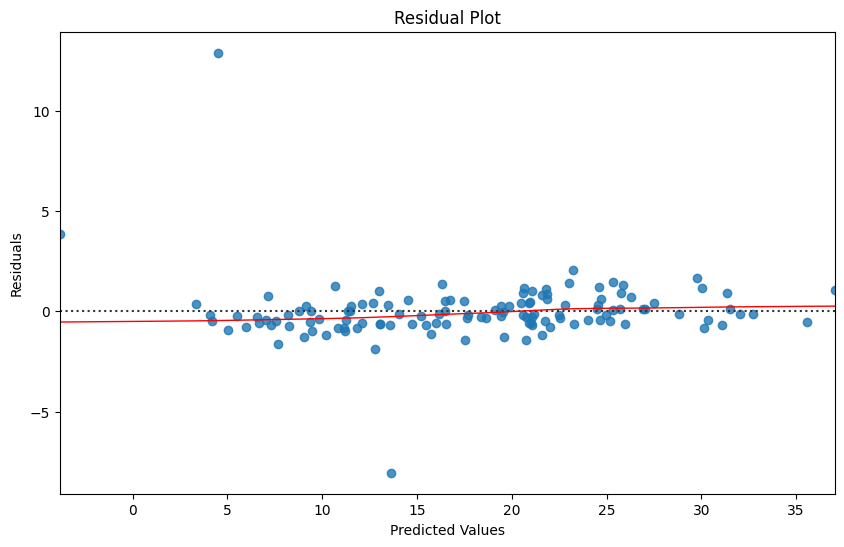

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

Y_pred_train = model.predict(X_train)
Y_pred_test = model.predict(X_test)

plt.figure(figsize=(10, 6))
sns.residplot(x=Y_pred_train, y=Y_train - Y_pred_train, lowess=True, line_kws={'color': 'red', 'lw': 1})
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

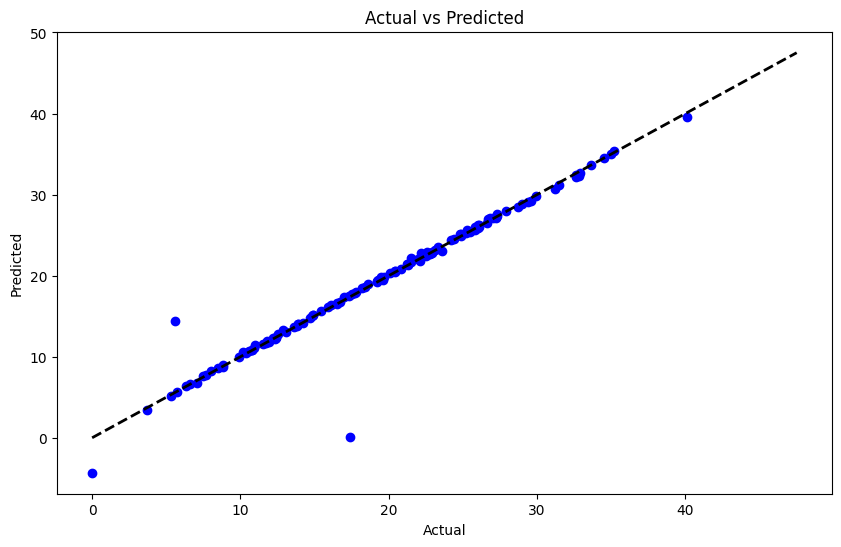

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(Y_test, Y_pred_test, color='blue')
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'k--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

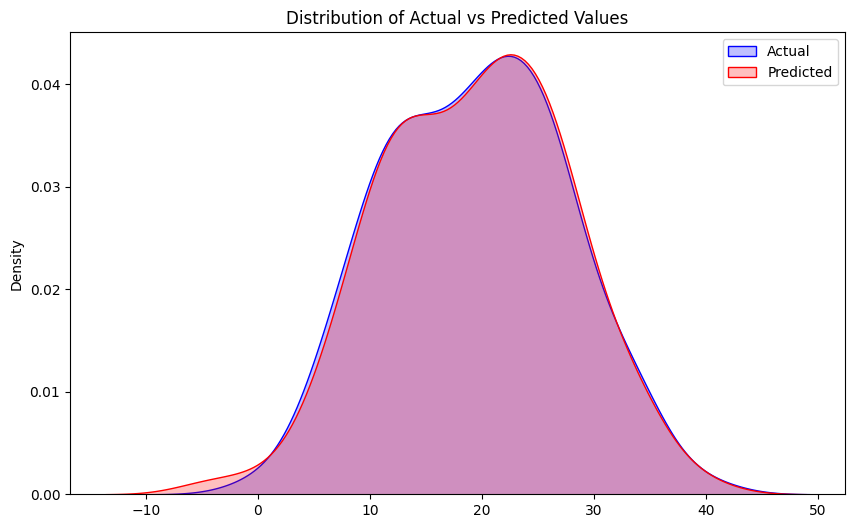

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(Y_test, color="blue", label="Actual", fill=True)
sns.kdeplot(Y_pred_test, color="red", label="Predicted", fill=True)
plt.title("Distribution of Actual vs Predicted Values")
plt.legend()
plt.show()

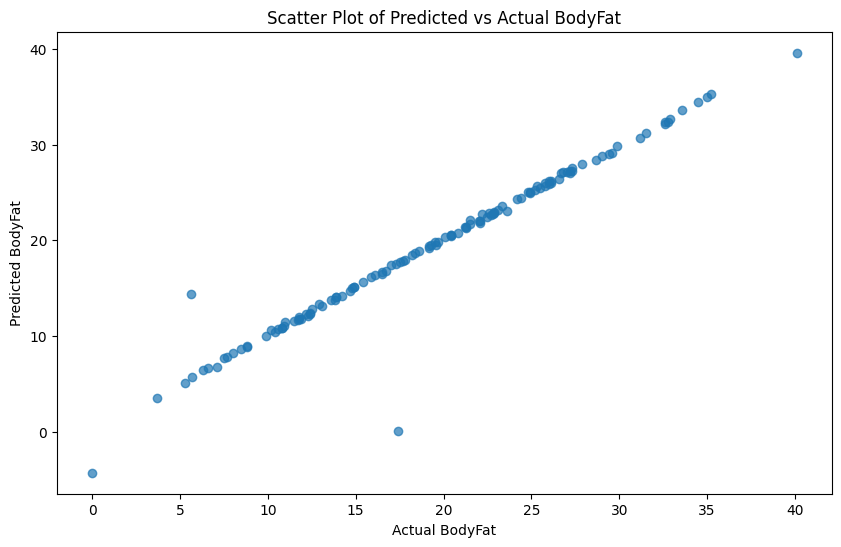

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(Y_test, Y_pred_test, alpha=0.7)
plt.xlabel("Actual BodyFat")
plt.ylabel("Predicted BodyFat")
plt.title("Scatter Plot of Predicted vs Actual BodyFat")
plt.show()


In [ ]:
# จากไฟล์ Body_Fat_Model.ipynb
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# การแบ่งข้อมูล Training และ Testing 50/50
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5)

# การเรียกใช้ Model
model = LinearRegression()
model.fit(X_train, y_train)